In [3]:
!pip install transformers datasets torch tqdm --quiet

from datasets import load_dataset
from transformers import AutoTokenizer, GPT2LMHeadModel, get_scheduler
from torch.optim import AdamW
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch, math, re, matplotlib.pyplot as plt

In [5]:
# SECTION 1: DATA LOADING AND CLEANING

# Load a small dataset for demonstration
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:5%]")
print(f"Number of text samples: {len(dataset)}")

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Number of text samples: 1836


In [6]:
# Text cleaning function (makes your version unique)
def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

dataset = dataset.map(lambda x: {"text": clean_text(x["text"])})
print(dataset[0]["text"][:200])


Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

In [7]:
# SECTION 2: TOKENIZATION AND GROUPIN

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token  # pad safely

# Tokenization
def tokenize_function(examples):
    return tokenizer(examples["text"], return_special_tokens_mask=False)

tokenized_ds = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

# Keep only 'input_ids' to avoid Arrow column mismatch
tokenized_ds = tokenized_ds.remove_columns(
    [col for col in tokenized_ds.column_names if col != "input_ids"]
)

# Grouping into fixed-length sequences
block_size = 128

def group_texts(examples):
    concatenated = sum(examples["input_ids"], [])
    total_len = (len(concatenated) // block_size) * block_size
    concatenated = concatenated[:total_len]
    result_input_ids = [
        concatenated[i:i + block_size] for i in range(0, total_len, block_size)
    ]
    return {"input_ids": result_input_ids, "labels": result_input_ids.copy()}

lm_ds = tokenized_ds.map(group_texts, batched=True, batch_size=1000)
print(f"LM training sequences: {len(lm_ds)}")

# Custom collate function
def collate_fn(batch):
    input_ids = torch.tensor([x["input_ids"] for x in batch], dtype=torch.long)
    labels = input_ids.clone()
    return {"input_ids": input_ids, "labels": labels}

train_loader = DataLoader(lm_ds, batch_size=8, shuffle=True, collate_fn=collate_fn)
print(next(iter(train_loader))["input_ids"].shape)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

LM training sequences: 971
torch.Size([8, 128])


In [8]:
# SECTION 3: MODEL, OPTIMIZER, AND TRAINING

model = GPT2LMHeadModel.from_pretrained("distilgpt2")
model.resize_token_embeddings(len(tokenizer))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
num_epochs = 1  # keep small for demo
num_training_steps = num_epochs * len(train_loader)
scheduler = get_scheduler("linear", optimizer=optimizer,
                          num_warmup_steps=0, num_training_steps=num_training_steps)

progress_bar = tqdm(range(num_training_steps))
loss_history = []
model.train()

for epoch in range(num_epochs):
    total_loss = 0
    for batch in train_loader:
        inputs = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=inputs, labels=labels)
        loss = outputs.loss

        # Backpropagation
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # added for stability
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

        total_loss += loss.item()
        loss_history.append(loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Average Training Loss: {avg_loss:.4f}")


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

100%|██████████| 122/122 [15:15<00:00,  6.23s/it]

Epoch 1 | Average Training Loss: 4.4176



Final Training Perplexity: 82.90


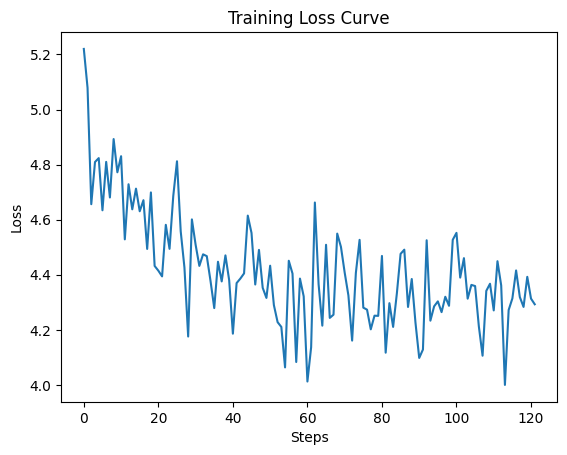

In [9]:
# SECTION 4: PERPLEXITY AND EVALUATION

avg_train_loss = sum(loss_history) / len(loss_history)
perplexity = math.exp(avg_train_loss)
print(f"\nFinal Training Perplexity: {perplexity:.2f}")

# visualize training curve
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()


In [10]:
# SECTION 5: TEXT GENERATION DEMO

prompt = "Artificial intelligence will"
inputs = tokenizer(prompt, return_tensors="pt").to(device)

outputs = model.generate(
    **inputs,
    max_length=60,
    temperature=0.8,
    top_p=0.9,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id
)

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("\n Generated Text \n")
print(generated_text)


 Generated Text 

Artificial intelligence will be used in research and development.


The basic premise is to create a complex system that can be used for a variety of purposes. The system consists of a variety of functions.
The function of a human being is to communicate with the world by looking at objects and


In [11]:
# SECTION 6: SAVE MODEL AND TOKENIZER

model.save_pretrained("lab1_gpt_model")
tokenizer.save_pretrained("lab1_gpt_model")
print("\nModel and tokenizer saved successfully!")


Model and tokenizer saved successfully!
